# **MÓDULO 39 - Exercicio - Aplicando XGboost**

Nessa atividade vocês usarão uma base já connhecida, a base de propensão a compra de carros.
Já utilizamos essa base antes, nessa atividade, você deve carregar a base, realizar os tratamentos necessários, rodar o XGBoost, encontrar as principais variaveis.
Vamos lá!

In [17]:
from xgboost import XGBClassifier
from xgboost import plot_importance
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

# 1. Carrega a base de dados, verifique os tipos de dados, dados faltantes e drop a coluna ID.


In [ ]:
# 1. Carregar a base de dados
df = pd.read_csv('CARRO_CLIENTES.csv')

# 2. Verificar os tipos de dados e informações gerais (linhas, colunas, memória)
print("--- Informações da Base de Dados ---")
df.info()

# 3. Verificar se existem dados faltantes (nulos)
print("\n--- Dados Faltantes por Coluna ---")
print(df.isnull().sum())

# 4. Dropar coluna ID
# Usamos axis=1 para indicar que estamos excluindo uma coluna (e não uma linha)
df = df.drop('User ID', axis=1)

# 5. Visualizar as primeiras linhas para confirmar a exclusão
print("\n--- Primeiras linhas após excluir 'User ID' ---")
display(df.head())

--- Informações da Base de Dados ---
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   User ID       1000 non-null   int64
 1   Gender        1000 non-null   str  
 2   Age           1000 non-null   int64
 3   AnnualSalary  1000 non-null   int64
 4   Purchased     1000 non-null   int64
dtypes: int64(4), str(1)
memory usage: 39.2 KB

--- Dados Faltantes por Coluna ---
User ID         0
Gender          0
Age             0
AnnualSalary    0
Purchased       0
dtype: int64

--- Primeiras linhas após excluir 'User ID' ---


,Gender,Age,AnnualSalary,Purchased
0,Male,35,20000,0
1,Male,40,43500,0
2,Male,49,74000,0
3,Male,40,107500,1
4,Male,25,79000,0


# 2. Aplique o Label Encoder para a coluna Gender e exclua a coluna categórica.

In [3]:
# 1. Instanciar (criar) o nosso codificador
le = LabelEncoder()

# 2. Aplicar o Label Encoder na coluna 'Gender'
# Isso vai criar uma nova coluna com os valores transformados em números (0 e 1)
df['Gender_encoded'] = le.fit_transform(df['Gender'])

# 3. Excluir a coluna categórica original (em formato de texto)
df = df.drop('Gender', axis=1)

# 4. Visualizar as primeiras linhas para confirmar a transformação
print("--- Primeiras linhas após o Label Encoder ---")
display(df.head())

--- Primeiras linhas após o Label Encoder ---


,Age,AnnualSalary,Purchased,Gender_encoded
0,35,20000,0,1
1,40,43500,0,1
2,49,74000,0,1
3,40,107500,1,1
4,25,79000,0,1


# 3. Faça a matriz de correlação e analise as váriaveis que parecem ter maior correlação com a váriavel target.

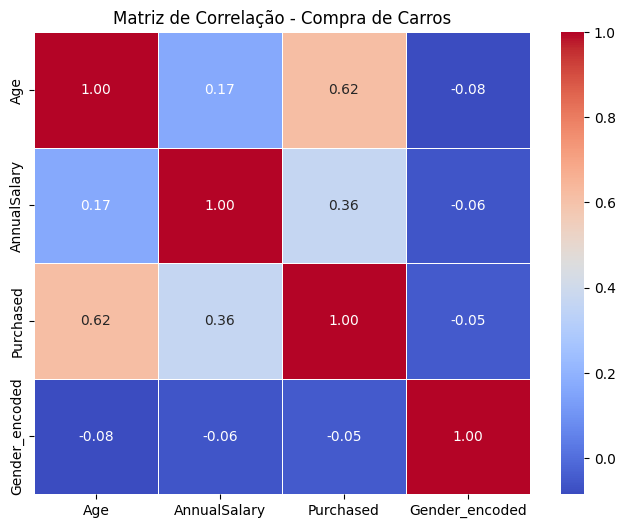

--- Correlação com a variável alvo (Purchased) ---
Purchased         1.000000
Age               0.616036
AnnualSalary      0.364974
Gender_encoded   -0.047211
Name: Purchased, dtype: float64


In [4]:
# 1. Calcular a matriz de correlação
matriz_correlacao = df.corr()

# 2. Criar um mapa de calor (Heatmap) para facilitar a visualização
plt.figure(figsize=(8, 6))
sns.heatmap(matriz_correlacao, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

# 3. Adicionar um título
plt.title('Matriz de Correlação - Compra de Carros')
plt.show()

# 4. Mostrar apenas a correlação das variáveis com o alvo ('Purchased') ordenado
print("--- Correlação com a variável alvo (Purchased) ---")
print(matriz_correlacao['Purchased'].sort_values(ascending=False))

Realizando a análise dos resultados, as variáveis com mairo correlação, são `Age` e `AnnualSalary`. Tendo uma correlação possitiva de 0.61 e 0.36 respectivaente com a variavel alvo.

# 4. Faça a separação da base em X e Y e em seguida nas bases de treino e teste.

In [5]:
# 1. Separar X (variáveis explicativas) e Y (variável alvo)
# O 'X' recebe tudo, exceto a coluna 'Purchased'
X = df.drop('Purchased', axis=1)

# O 'y' recebe APENAS a coluna 'Purchased'
y = df['Purchased']

# 2. Separar em bases de treino e teste
# test_size=0.2 significa que 20% dos dados vão para teste e 80% para treino
# random_state=42 garante que a divisão aleatória seja a mesma toda vez que rodarmos o código
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Verificar o tamanho das bases geradas para confirmar
print(f"Tamanho de X_train (Dados de Treino): {X_train.shape}")
print(f"Tamanho de X_test (Dados de Teste): {X_test.shape}")
print(f"Tamanho de y_train (Respostas de Treino): {y_train.shape}")
print(f"Tamanho de y_test (Respostas de Teste): {y_test.shape}")

Tamanho de X_train (Dados de Treino): (800, 3)
Tamanho de X_test (Dados de Teste): (200, 3)
Tamanho de y_train (Respostas de Treino): (800,)
Tamanho de y_test (Respostas de Teste): (200,)


# 5. Treino o modelo Xgboost com sua base de treino.
Pesquise alguns hyperparametros na bibllioteca para utilizar, utilize ao menos 2.

In [11]:
# 1. Definir os hiperparâmetros
# Escolhi 3 hiperparâmetros muito comuns e importantes no XGBoost:
parametros = {
    'max_depth': 3,           # Profundidade máxima de cada árvore
    'learning_rate': 0.1,     # Taxa de aprendizado (o tamanho do passo a cada árvore)
    'n_estimators': 100,      # Número total de árvores que serão construídas
    'random_state': 42       # Para garantir que os resultados sejam reproduzíveis
}

# 2. Instanciar o modelo XGBoost com os parâmetros definidos
# Usamos o XGBClassifier porque nosso problema é de Classificação (comprar=1 ou não comprar=0)
modelo_xgb = XGBClassifier(**parametros)

# 3. Treinar o modelo usando a base de treino
modelo_xgb.fit(X_train, y_train)

print("Modelo XGBoost treinado com sucesso!")#SEU CÓDIGO AQUI

Modelo XGBoost treinado com sucesso!


# 6. Realize as previsões para a base de teste e traga as probabilidades das previsões.

In [14]:
# 1. Realizar as previsões de classe (o veredito final: 0 ou 1)
y_pred = modelo_xgb.predict(X_test)

# 2. Realizar as previsões de probabilidade (o nível de certeza do modelo)
y_proba = modelo_xgb.predict_proba(X_test)

# 3. Criar uma tabela (DataFrame) para visualizar tudo junto de forma organizada
resultados = pd.DataFrame({
    'Veredito Final': y_pred,
    'Chance de NÃO Comprar (0)': y_proba[:, 0], # Pega a primeira coluna
    'Chance de COMPRAR (1)': y_proba[:, 1]      # Pega a segunda coluna
})

# 4. Transformar os números decimais em Porcentagem (%)
resultados['Chance de NÃO Comprar (0)'] = (resultados['Chance de NÃO Comprar (0)'] * 100).map('{:.2f}%'.format)
resultados['Chance de COMPRAR (1)'] = (resultados['Chance de COMPRAR (1)'] * 100).map('{:.2f}%'.format)

# 5. Visualizar os 5 primeiros resultados
print("--- Primeiras 5 Previsões (Formatadas) ---")
display(resultados.head())

--- Primeiras 5 Previsões (Formatadas) ---


,Veredito Final,Chance de NÃO Comprar (0),Chance de COMPRAR (1)
0,0,80.60%,19.40%
1,1,2.47%,97.53%
2,0,99.92%,0.08%
3,0,71.74%,28.26%
4,1,28.27%,71.73%


# 7. Faça a transformação das probabilidades nas previsões binárias e avalie o desempenho do modelo.

Acurácia do Modelo: 90.50%

--- Relatório de Classificação ---
              precision    recall  f1-score   support

           0       0.89      0.95      0.92       112
           1       0.93      0.85      0.89        88

    accuracy                           0.91       200
   macro avg       0.91      0.90      0.90       200
weighted avg       0.91      0.91      0.90       200



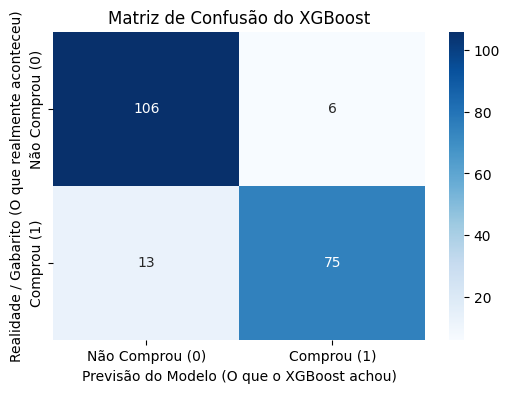

In [ ]:
# 1. Avaliar a Acurácia (Taxa de acerto geral)
acuracia = accuracy_score(y_test, y_pred)
print(f"Acurácia do Modelo: {acuracia * 100:.2f}%\n")

# 2. Gerar o Relatório de Classificação
print("--- Relatório de Classificação ---")
print(classification_report(y_test, y_pred))

# 3. Criar e visualizar a Matriz de Confusão
matriz_confusao = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
# Criando um Heatmap bem visual para a Matriz
sns.heatmap(matriz_confusao, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Não Comprou (0)', 'Comprou (1)'], 
            yticklabels=['Não Comprou (0)', 'Comprou (1)'])

plt.title('Matriz de Confusão do XGBoost')
plt.xlabel('Previsão do Modelo (O que o XGBoost achou)')
plt.ylabel('Realidade / Gabarito (O que realmente aconteceu)')
plt.show()

# 8. Traga a lista com a feature importance.
As features mais importantes são as mesmas que indicaram maior correlação na matriz de correlação?

--- Tabela de Importância das Variáveis ---


,Variável,Importância (Score)
0,Age,0.616965
1,AnnualSalary,0.323019
2,Gender_encoded,0.060015


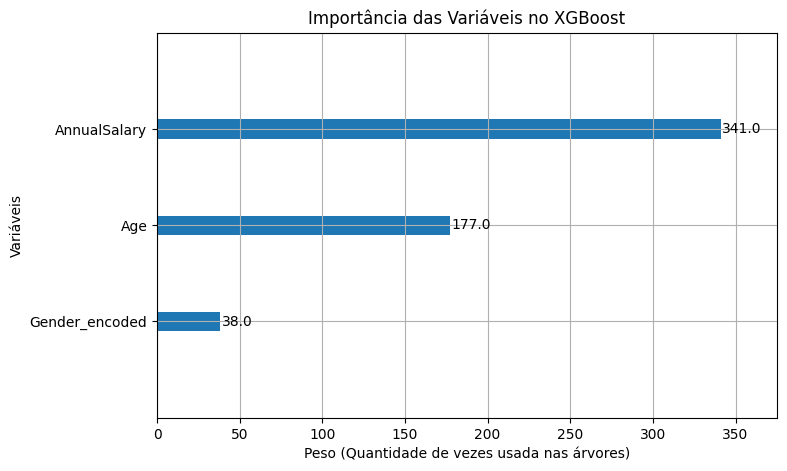

In [18]:
# 1. Extrair a importância das variáveis do modelo treinado
importancias = modelo_xgb.feature_importances_
nomes_features = X_train.columns

# 2. Criar uma tabela (DataFrame) para organizar do maior para o menor
df_importancia = pd.DataFrame({
    'Variável': nomes_features,
    'Importância (Score)': importancias
})
df_importancia = df_importancia.sort_values(by='Importância (Score)', ascending=False)

print("--- Tabela de Importância das Variáveis ---")
display(df_importancia)

# 3. Gerar o gráfico visual nativo do XGBoost
# O parâmetro importance_type='weight' mostra quantas vezes a variável foi usada para dividir as árvores
plt.rcParams['figure.figsize'] = [8, 5]
plot_importance(modelo_xgb, importance_type='weight', 
                title='Importância das Variáveis no XGBoost', 
                xlabel='Peso (Quantidade de vezes usada nas árvores)', 
                ylabel='Variáveis')
plt.show()

Sobre a pergunta das features. Avaliando os dados da etapa 3 das correlações com a tabela de importância das variáveis. Sim, As variáveis que tinham maior correlação estatística também se provaram as mais importantes para o algoritmo construir as regras de decisão.